# 16 — THEME trading signals vs price

Notebook 15, but through the THEME lens only: every chart and the report
card run on the theme signals (`trade_signals.parquet`), each theme drawn
against its anchor ETF's price. Individual-ticker signals are notebook 15's
job.

Charts show the theme NAME (with its ETF), so a cluster of BUY arrows reads
as "the crowd is piling into uranium", not just "URA is signalled".

In [1]:
import os, sys
import pandas as pd
import matplotlib.pyplot as plt

ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
sys.path.insert(0, ROOT)
P = os.path.join(ROOT, 'data', 'processed')
PRICES_PATH = os.path.join(ROOT, 'data', 'prices', 'prices.parquet')

# window: the PIPELINE_* env vars (set by update_data.py, including its
# --start/--end overrides) win; otherwise fall back to the constants at the
# top of update_data.py. Same toggle as live vs backtest either way.
import update_data
START_DATE = os.environ.get('PIPELINE_START_DATE') or update_data.START_DATE
END_DATE = os.environ.get('PIPELINE_END_DATE')
if END_DATE is None:
    END_DATE = update_data.END_DATE
WIN_LO = pd.to_datetime(START_DATE)
WIN_HI = pd.to_datetime(END_DATE) if END_DATE else None
print('window:', WIN_LO.date(), '->', (WIN_HI.date() if WIN_HI is not None else 'LIVE (newest)'))

def clip_series(s):
    s = s[s.index >= WIN_LO]
    return s if WIN_HI is None else s[s.index <= WIN_HI]

def clip_dates(df, col):
    df = df[df[col] >= WIN_LO]
    return df if WIN_HI is None else df[df[col] <= WIN_HI]

def load_prices():
    if not os.path.exists(PRICES_PATH):
        raise FileNotFoundError('prices.parquet not found - run  python pull_bloomberg_prices.py  first.')
    px = pd.read_parquet(PRICES_PATH); px['date'] = pd.to_datetime(px['date'])
    return px

def price_series(prices, symbol):
    # daily close, then made CONTINUOUS (forward-fill weekends/holidays) so the
    # line is smooth with no gaps. Clip to the window.
    one = prices[prices['symbol'] == symbol].sort_values('date')
    s = one.set_index('date')['px_last']
    if not s.empty:
        s = s.asfreq('D').ffill()
    return clip_series(s)


# --- x-axis tick control (X_TICKS in the parameters cell) ---
# 'auto' = matplotlib decides; 'W' = a label every week; 'M' = every month.
# Weekly labels are only readable on windows up to ~6 months - use
# PLOT_LAST_DAYS to zoom in first.
import matplotlib.dates as mdates

def set_date_ticks(ax, ticks):
    if ticks == 'W':
        ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))  # Mondays
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %y'))
    elif ticks == 'M':
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')

window: 2022-01-01 -> 2023-01-01


In [2]:
HOW_MANY = 6
FREQ = 'W'        # 'W' weekly (smooth price line), 'D' daily, 'M' monthly
X_TICKS = 'auto'  # x-axis labels: 'auto', 'W' (weekly), 'M' (monthly)
PLOT_LAST_DAYS = None   # e.g. 120 = zoom to the last 120 days (None = whole window)
# --- high-conviction clustering: several same-direction signals close together
# on one symbol are ONE conviction event, not several trades ---
CLUSTER_DAYS = 10  # same-side signals within this many days merge into a cluster
CONV_MIN     = 2   # a cluster needs at least this many signals to count as
                   # HIGH CONVICTION (big arrow on the charts)
pd.set_option('display.max_colwidth', None); pd.set_option('display.width', 200)

auto themes (most signalled): ['china_geopolitics', 'gold_metals', 'small_caps', 'robotics_automation', 'ev_clean_energy', 'semiconductors']

china_geopolitics (KWEB): 8 signals - how each was decided
action_date action  score    att_z    conv_z  sent_5d_chg                                                                                                                                                                         reason
 2022-01-05   SELL      3 1.077821 -0.997338    -0.187667                          SELL KWEB: mood deteriorating (5d sentiment -0.188 < 0) + crowded-top divergence ACTIVE (crowd up, mood down) + Reddit AND X both rising -> score 3/5
 2022-05-27    BUY      4 2.080468  0.960913     0.003858                         BUY KWEB: attention surged (z +2.08 > 2.0) + mood improving (5d sentiment +0.004 > 0) + no crowded-top warning + Reddit AND X both rising -> score 4/5
 2022-06-15   SELL      3 1.387228  0.669570    -0.141853                          SELL KWEB: mood d

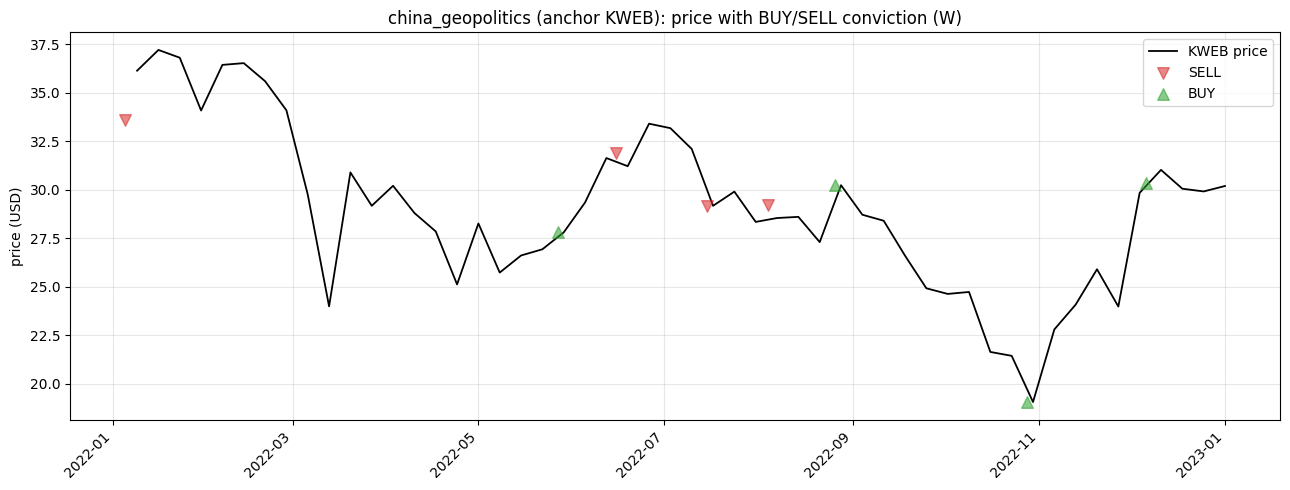


gold_metals (GLD): 8 signals - how each was decided
action_date action  score    att_z    conv_z  sent_5d_chg                                                                                                                                                                reason
 2022-01-23   SELL      3 3.033956 -0.497883    -0.137255          SELL GLD: attention surged (z +3.03 > 2.0) + mood deteriorating (5d sentiment -0.137 < 0) + crowded-top divergence ACTIVE (crowd up, mood down) -> score 3/5
 2022-02-15   SELL      3 2.341504  0.360614    -0.169244          SELL GLD: attention surged (z +2.34 > 2.0) + mood deteriorating (5d sentiment -0.169 < 0) + crowded-top divergence ACTIVE (crowd up, mood down) -> score 3/5
 2022-05-21    BUY      4 2.371384 -0.521262     0.150095                 BUY GLD: attention surged (z +2.37 > 2.0) + mood improving (5d sentiment +0.150 > 0) + no crowded-top warning + Reddit AND X both rising -> score 4/5
 2022-06-17    BUY      4 2.068277  0.414184     0.

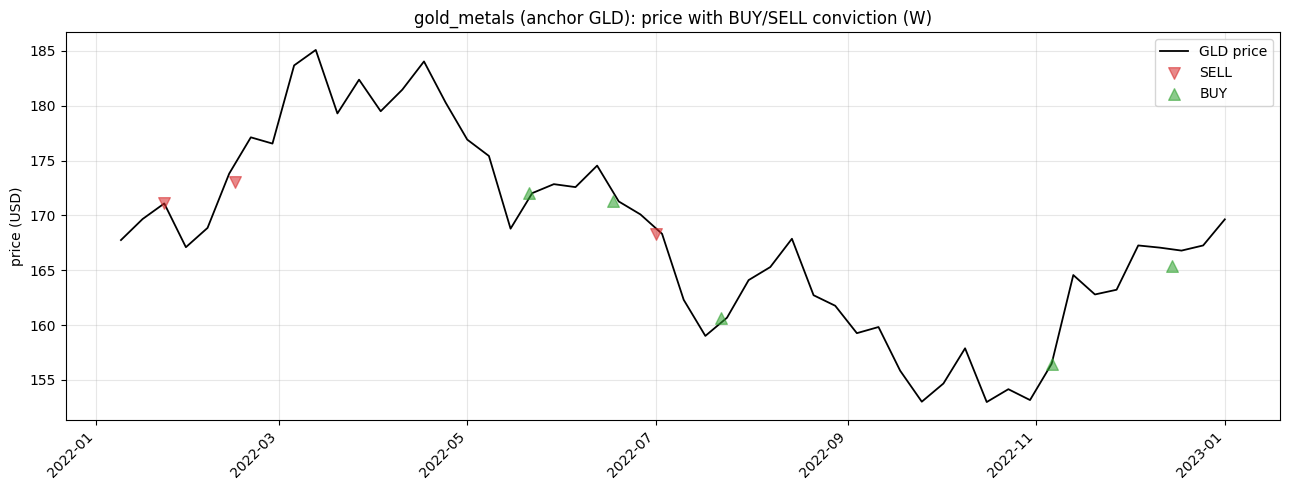


small_caps (IWM): 8 signals - how each was decided
action_date action  score    att_z    conv_z  sent_5d_chg                                                                                                                                                                                  reason
 2022-01-06    BUY      4 3.470347  1.039226     0.045385                                   BUY IWM: attention surged (z +3.47 > 2.0) + mood improving (5d sentiment +0.045 > 0) + no crowded-top warning + Reddit AND X both rising -> score 4/5
 2022-01-07   SELL      4 3.208687  0.319719    -0.104040 SELL IWM: attention surged (z +3.21 > 2.0) + mood deteriorating (5d sentiment -0.104 < 0) + crowded-top divergence ACTIVE (crowd up, mood down) + Reddit AND X both rising -> score 4/5
 2022-05-29   SELL      3 3.175446  1.693192    -0.129630                            SELL IWM: attention surged (z +3.18 > 2.0) + mood deteriorating (5d sentiment -0.130 < 0) + crowded-top divergence ACTIVE (crowd up, mood

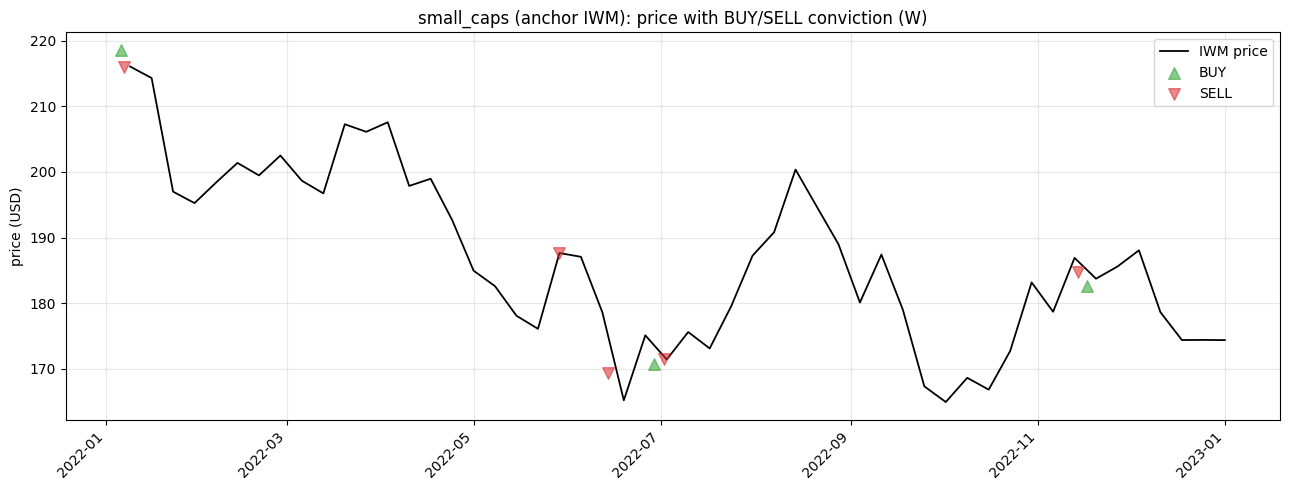


robotics_automation (BOTZ): 8 signals - how each was decided
action_date action  score    att_z    conv_z  sent_5d_chg                                                                                                                                                                                                    reason
 2022-04-27   SELL      3 3.378272  1.086458    -0.101961                                             SELL BOTZ: attention surged (z +3.38 > 2.0) + mood deteriorating (5d sentiment -0.102 < 0) + crowded-top divergence ACTIVE (crowd up, mood down) -> score 3/5
 2022-05-23   SELL      4 1.035574 -2.813913    -0.214286 SELL BOTZ: mood deteriorating (5d sentiment -0.214 < 0) + crowd leaning bearish (conviction z -2.81 < -2.0) + crowded-top divergence ACTIVE (crowd up, mood down) + Reddit AND X both rising -> score 4/5
 2022-07-23    BUY      4 2.080183  1.269562     0.300000                                                    BUY BOTZ: attention surged (z +2.08 > 2.0) + mood

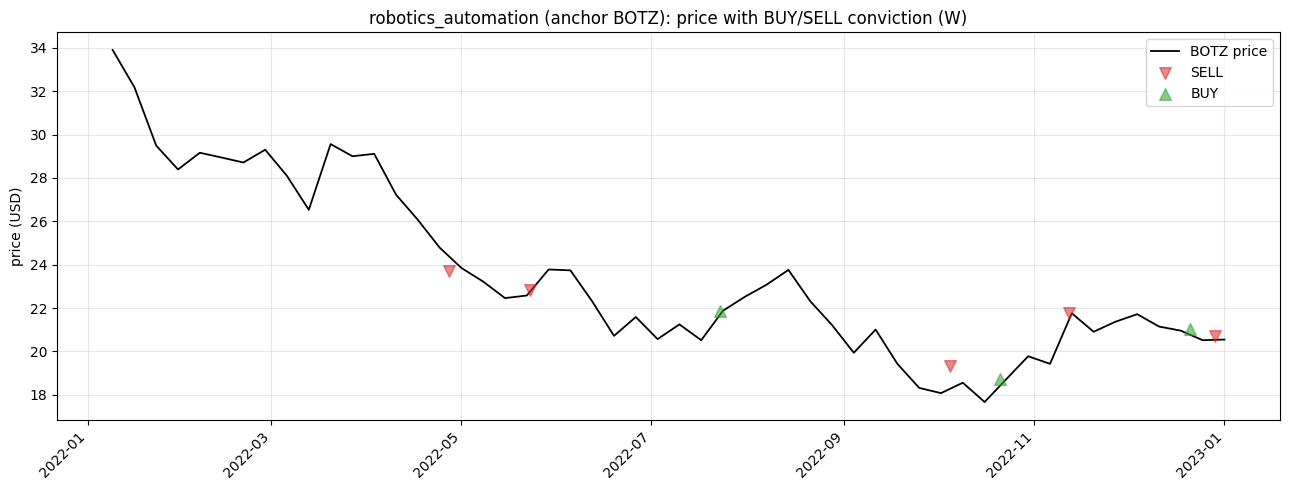


ev_clean_energy (ICLN): 8 signals - how each was decided
action_date action  score    att_z    conv_z  sent_5d_chg                                                                                                                                                                                                    reason
 2022-04-28   SELL      3 2.331099 -0.193055    -0.106873                                             SELL ICLN: attention surged (z +2.33 > 2.0) + mood deteriorating (5d sentiment -0.107 < 0) + crowded-top divergence ACTIVE (crowd up, mood down) -> score 3/5
 2022-05-24   SELL      4 1.152321 -2.004441    -0.106993 SELL ICLN: mood deteriorating (5d sentiment -0.107 < 0) + crowd leaning bearish (conviction z -2.00 < -2.0) + crowded-top divergence ACTIVE (crowd up, mood down) + Reddit AND X both rising -> score 4/5
 2022-07-14   SELL      3 1.104846 -0.056621    -0.109596                                                     SELL ICLN: mood deteriorating (5d sentiment -0.110 <

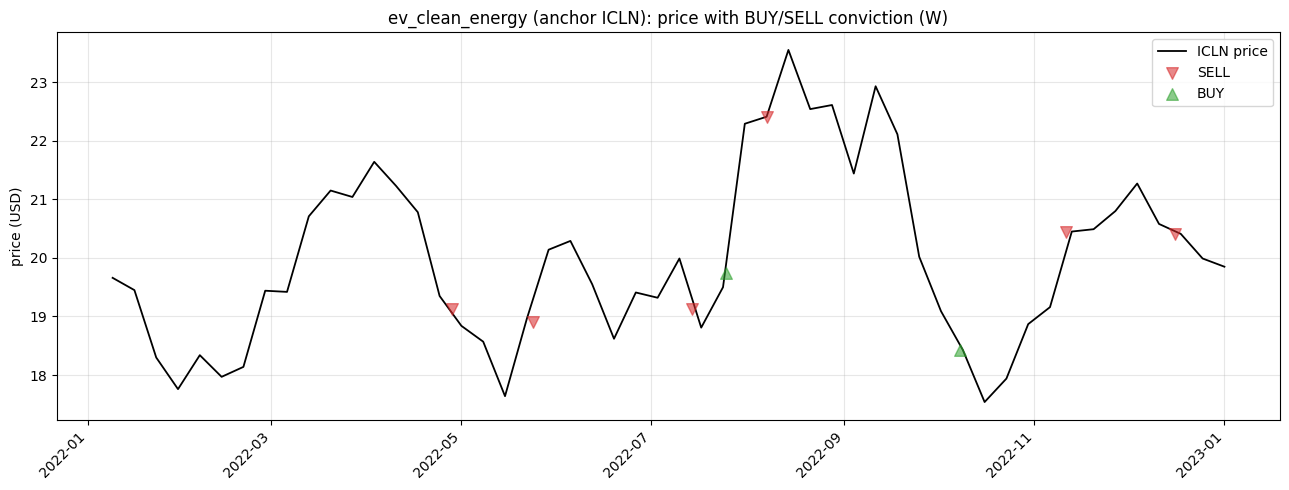


semiconductors (SMH): 8 signals - how each was decided
action_date action  score     att_z    conv_z  sent_5d_chg                                                                                                                                                                                  reason
 2022-01-06   SELL      3  1.382031  0.279238    -0.166403                                    SELL SMH: mood deteriorating (5d sentiment -0.166 < 0) + crowded-top divergence ACTIVE (crowd up, mood down) + Reddit AND X both rising -> score 3/5
 2022-07-02   SELL      4  2.399168 -0.481617    -0.308166 SELL SMH: attention surged (z +2.40 > 2.0) + mood deteriorating (5d sentiment -0.308 < 0) + crowded-top divergence ACTIVE (crowd up, mood down) + Reddit AND X both rising -> score 4/5
 2022-07-17    BUY      4  0.394400  2.195655     0.087868                   BUY SMH: mood improving (5d sentiment +0.088 > 0) + crowd leaning bullish (conviction z +2.20 > 2.0) + no crowded-top warning + Reddit AND

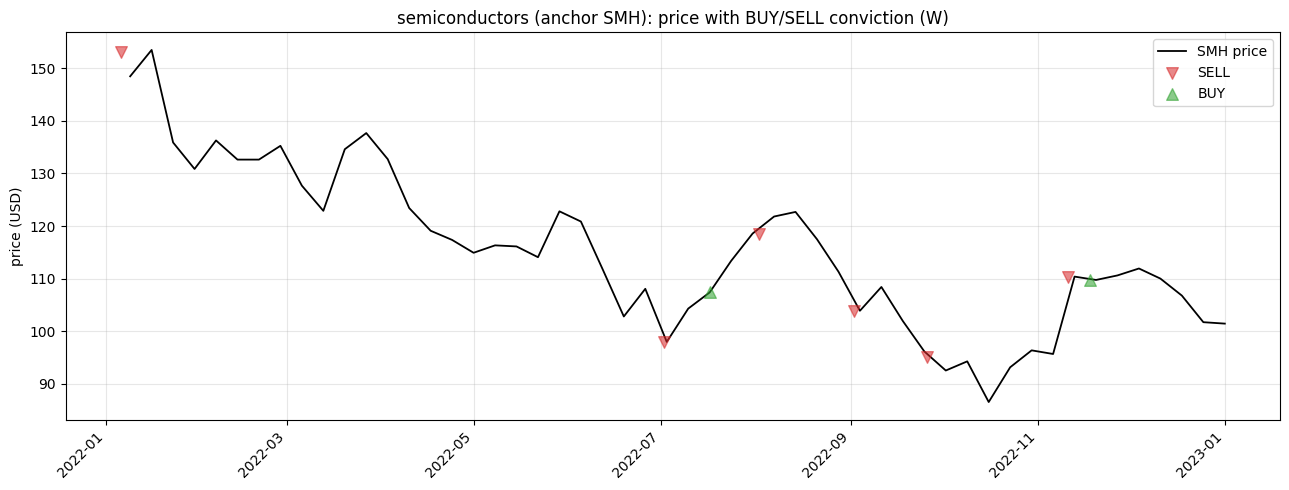

In [3]:
theme = pd.read_parquet(os.path.join(P, 'trade_signals.parquet'))
theme['action_date'] = pd.to_datetime(theme['action_date'])
theme = clip_dates(theme, 'action_date')
if PLOT_LAST_DAYS and len(theme):                    # zoom: recent stretch only
    WIN_LO = max(WIN_LO, theme['action_date'].max() - pd.Timedelta(days=PLOT_LAST_DAYS))
    theme = theme[theme['action_date'] >= WIN_LO]

# THEMES ONLY here: symbol = the theme's anchor ETF, but the theme name is
# kept for titles/tables so the charts read as trades on ideas, not tickers.
DET = ['action_date', 'action', 'score', 'att_z', 'conv_z', 'sent_5d_chg', 'reason']
sig_all = theme.rename(columns={'etf': 'symbol'})[['symbol', 'theme'] + DET]
themes_ranked = sig_all['theme'].value_counts().head(HOW_MANY).index.tolist()
print('auto themes (most signalled):', themes_ranked)

prices = load_prices()

def cluster_signals(one_symbol_df, max_gap_days=CLUSTER_DAYS):
    """Group SAME-SIDE signals whose neighbour is within max_gap_days.
    Several signals close together = the model repeating itself = one
    HIGH-CONVICTION event, not several separate trades."""
    clusters = []
    for side in ('BUY', 'SELL'):
        rows = one_symbol_df[one_symbol_df['action'] == side].sort_values('action_date')
        dates = list(rows['action_date'])
        if not dates:
            continue
        cur = [dates[0]]
        for dt in dates[1:]:
            if (dt - cur[-1]).days <= max_gap_days:
                cur.append(dt)
            else:
                clusters.append({'side': side, 'dates': cur, 'n': len(cur),
                                 'start': cur[0], 'end': cur[-1]})
                cur = [dt]
        clusters.append({'side': side, 'dates': cur, 'n': len(cur),
                         'start': cur[0], 'end': cur[-1]})
    return sorted(clusters, key=lambda c: c['start'])

for theme_name in themes_ranked:
    s = sig_all[sig_all['theme'] == theme_name]
    symbol = s['symbol'].iloc[0]
    px_daily = price_series(prices, symbol)
    if px_daily.empty:
        print('skip', theme_name, f'- no price rows for {symbol} - re-run pull_bloomberg_prices.py')
        continue

    # --- the decision detail for this theme ---
    print('\n' + '=' * 90)
    print(f'{theme_name} ({symbol}): {len(s)} signals - how each was decided')
    print('=' * 90)
    print(s[DET].to_string(index=False))

    # --- the chart ---
    px_line = px_daily if FREQ == 'D' else px_daily.resample(FREQ).last()
    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(px_line.index, px_line.values, color='black', linewidth=1.3, label=f'{symbol} price')
    clusters = cluster_signals(s)
    done_labels = set()
    for cl in clusters:
        mid = cl['dates'][len(cl['dates']) // 2]           # middle of the cluster
        price_at = px_daily.asof(mid)
        if pd.isna(price_at):
            continue
        color = 'tab:green' if cl['side'] == 'BUY' else 'tab:red'
        marker = '^' if cl['side'] == 'BUY' else 'v'
        if cl['n'] >= CONV_MIN:
            size = min(200 + 180 * (cl['n'] - CONV_MIN + 1), 900)
            label = f"HIGH CONVICTION {cl['side']}" if f"hc{cl['side']}" not in done_labels else None
            done_labels.add(f"hc{cl['side']}")
            ax.scatter([mid], [price_at], marker=marker, s=size, color=color,
                       edgecolors='black', linewidths=1.5, zorder=6, label=label)
            ax.annotate(f"x{cl['n']}", (mid, price_at), textcoords='offset points',
                        xytext=(0, 14 if cl['side'] == 'BUY' else -20),
                        fontsize=11, fontweight='bold', ha='center', color=color)
        else:
            label = cl['side'] if cl['side'] not in done_labels else None
            done_labels.add(cl['side'])
            ax.scatter([mid], [price_at], marker=marker, s=70, color=color,
                       alpha=0.55, zorder=5, label=label)
    ax.set_ylabel('price (USD)')
    ax.set_title(f'{theme_name} (anchor {symbol}): price with BUY/SELL conviction ({FREQ})')
    set_date_ticks(ax, X_TICKS)
    ax.legend(); ax.grid(True, alpha=0.3); fig.tight_layout(); plt.show()

## Signal report card — does the model work?

Three views over EVERY signal in the window (not just the top symbols above):

1. **Forward returns** — average price move 5/10/20 days AFTER acting on a
   signal. BUYs should skew positive, SELLs negative. This is the visual
   check: change the window in `update_data.py`, re-run, and compare eras.
2. **Score vs outcome** — do 5/5-score signals really beat 4/5? If yes,
   raising `MIN_SCORE` in notebook 10 is free selectivity.
3. **Signal frequency** — how many calls per week the model makes. Spikes =
   hot regimes; a flood of signals is a reason to tighten the knobs.

113 signals with price data (of 124 total)
BUY :  48 signals | 10d hit rate   50% | avg 10d return +0.65%
SELL:  65 signals | 10d hit rate   48% | avg 10d return +0.28%


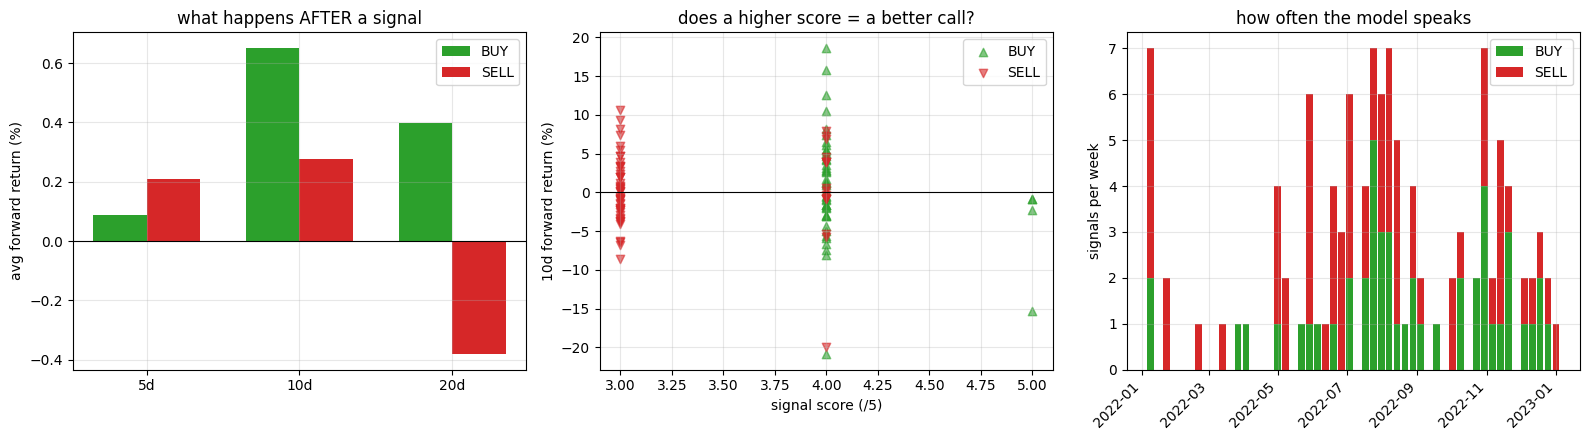

In [4]:
# ==== SIGNAL REPORT CARD ====
HORIZONS = [5, 10, 20]          # trading-day-ish horizons (calendar days, ffilled)

# price series once per symbol (they are ffilled daily, so .asof works cleanly)
px_cache = {sym: price_series(prices, sym) for sym in sig_all['symbol'].unique()}

rows = []
for _, s in sig_all.iterrows():
    px = px_cache.get(s['symbol'], pd.Series(dtype=float))
    if px.empty:
        continue
    p0 = px.asof(s['action_date'])
    if pd.isna(p0):
        continue
    row = {'symbol': s['symbol'], 'action': s['action'],
           'score': int(s['score']), 'action_date': s['action_date']}
    for h in HORIZONS:
        p1 = px.asof(s['action_date'] + pd.Timedelta(days=h))
        # signals too close to the end of the data have no forward price yet
        row[f'ret_{h}d'] = (p1 / p0 - 1) * 100 if pd.notna(p1) and p1 != p0 else None
    rows.append(row)
perf = pd.DataFrame(rows)
print(f'{len(perf)} signals with price data (of {len(sig_all)} total)')

if len(perf):
    # --- hit rate: BUYs that went up, SELLs that went down (10d horizon) ---
    for side, good in [('BUY', 1), ('SELL', -1)]:
        r = perf[perf['action'] == side]['ret_10d'].dropna()
        if len(r):
            hits = (r * good > 0).mean() * 100
            print(f'{side:<4}: {len(r):>3} signals | 10d hit rate {hits:4.0f}% '
                  f'| avg 10d return {r.mean():+.2f}%')

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    # 1. average forward return by side and horizon
    ax = axes[0]
    width = 0.35
    xs = range(len(HORIZONS))
    for off, (side, color) in enumerate([('BUY', 'tab:green'), ('SELL', 'tab:red')]):
        means = [perf[perf['action'] == side][f'ret_{h}d'].mean() for h in HORIZONS]
        ax.bar([x + off * width for x in xs], means, width, label=side, color=color)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks([x + width / 2 for x in xs])
    ax.set_xticklabels([f'{h}d' for h in HORIZONS])
    ax.set_ylabel('avg forward return (%)')
    ax.set_title('what happens AFTER a signal')
    ax.legend(); ax.grid(True, alpha=0.3)

    # 2. score vs 10-day outcome
    ax = axes[1]
    for side, color, marker in [('BUY', 'tab:green', '^'), ('SELL', 'tab:red', 'v')]:
        sub = perf[perf['action'] == side].dropna(subset=['ret_10d'])
        ax.scatter(sub['score'], sub['ret_10d'], color=color, marker=marker,
                   alpha=0.6, label=side)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xlabel('signal score (/5)'); ax.set_ylabel('10d forward return (%)')
    ax.set_title('does a higher score = a better call?')
    ax.legend(); ax.grid(True, alpha=0.3)

    # 3. signals per week over time
    ax = axes[2]
    weekly = (perf.set_index('action_date').groupby('action')
              .resample('W').size().unstack(0, fill_value=0) if len(perf) else None)
    if weekly is not None and len(weekly):
        if 'BUY' in weekly:
            ax.bar(weekly.index, weekly['BUY'], width=6, color='tab:green', label='BUY')
        if 'SELL' in weekly:
            ax.bar(weekly.index, weekly.get('SELL', 0), width=6, color='tab:red',
                   bottom=weekly.get('BUY', 0), label='SELL')
    ax.set_ylabel('signals per week'); ax.set_title('how often the model speaks')
    set_date_ticks(ax, X_TICKS)
    ax.legend(); ax.grid(True, alpha=0.3)

    fig.tight_layout(); plt.show()
else:
    print('no signals with price coverage in this window - '
          'run update_data.py / pull_bloomberg_prices.py first')

## The 1-week lookback — the live trading table

This is the primary trading metric. For every theme, compare the
**last 7 days** against the 7 days before:

- `velocity_chg` — mentions last 7d minus prior 7d (is attention accelerating?)
- `conv_now` — latest conviction_z (the 7-day bull-pressure z from notebook 09)
- `conv_chg_7d` — conviction now minus one week ago (is the crowd getting MORE convinced?)

Big positive `velocity_chg` + rising `conv_chg_7d` = the setup the BUY signals look for.

1-WEEK LOOKBACK (data through 2023-01-01) - sorted by attention change
                     mentions_7d  mentions_prior7d  velocity_chg  conv_now  conv_week_ago  conv_chg_7d
theme                                                                                                 
financials                 622.0             545.0          77.0     -0.09          -0.33         0.24
real_estate                291.0             225.0          66.0      0.17          -0.37         0.54
ai_megacap                 534.0             502.0          32.0     -0.46          -0.53         0.07
ev_clean_energy            395.0             372.0          23.0     -0.54          -0.59         0.04
cybersecurity               64.0              43.0          21.0     -0.66          -0.00        -0.66
travel_airlines             40.0              21.0          19.0      0.03           0.14        -0.12
meme_stocks                244.0             226.0          18.0     -0.14          -0.14         0.00
ai

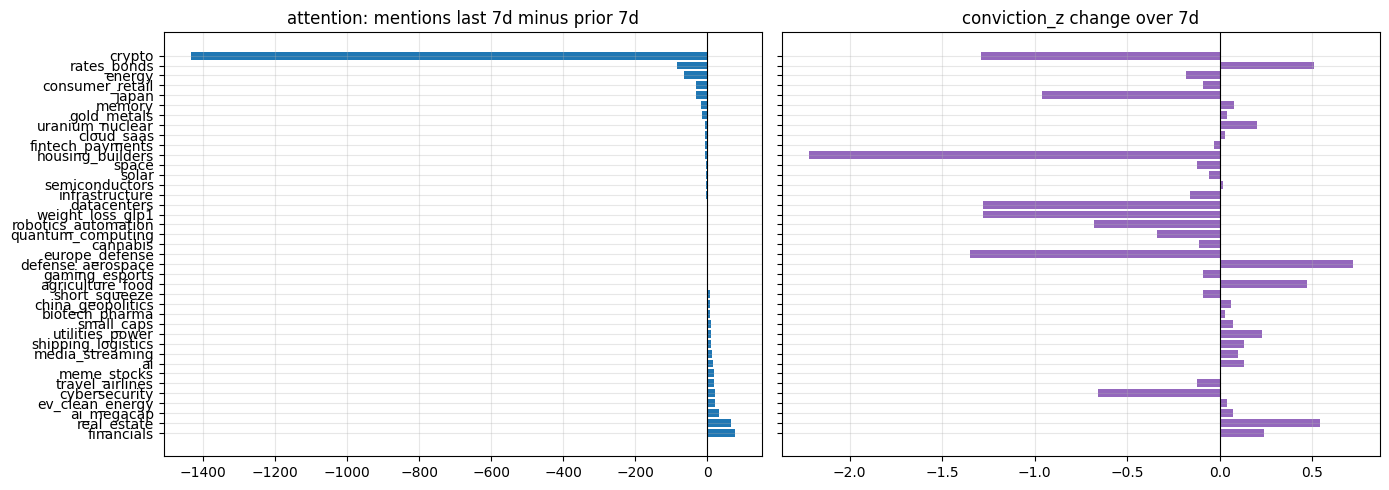

In [5]:
# ==== LIVE 1-WEEK LOOKBACK - the trading table ====
counts = pd.read_parquet(os.path.join(P, 'daily_theme_counts.parquet'))
# the aggregates carry 'mention_count'; older notebook-04 output carries
# keyword/inferred columns instead - handle both so this never breaks
if 'mention_count' not in counts.columns:
    counts['mention_count'] = (counts.get('keyword_count', 0)
                               + counts.get('inferred_count', 0))
counts['date'] = pd.to_datetime(counts['date'])
counts = clip_dates(counts, 'date')
end = counts['date'].max()

last7 = counts[counts['date'] > end - pd.Timedelta(days=7)]
prior7 = counts[(counts['date'] <= end - pd.Timedelta(days=7))
                & (counts['date'] > end - pd.Timedelta(days=14))]
tbl = pd.concat([
    last7.groupby('theme')['mention_count'].sum().rename('mentions_7d'),
    prior7.groupby('theme')['mention_count'].sum().rename('mentions_prior7d'),
], axis=1).fillna(0)
tbl['velocity_chg'] = tbl['mentions_7d'] - tbl['mentions_prior7d']

conv = pd.read_parquet(os.path.join(P, 'daily_theme_conviction.parquet'))
conv['date'] = pd.to_datetime(conv['date'])
conv = clip_dates(conv, 'date')
latest = conv.sort_values('date').groupby('theme')['conviction_z'].last().rename('conv_now')
week_ago = (conv[conv['date'] <= end - pd.Timedelta(days=7)].sort_values('date')
            .groupby('theme')['conviction_z'].last().rename('conv_week_ago'))
tbl = tbl.join(latest).join(week_ago)
tbl['conv_chg_7d'] = tbl['conv_now'] - tbl['conv_week_ago']
tbl = tbl.sort_values('velocity_chg', ascending=False).round(2)

print(f'1-WEEK LOOKBACK (data through {end.date()}) - sorted by attention change')
print(tbl.to_string())

# visual: attention change vs conviction change, one bar pair per theme
plot = tbl.dropna(subset=['conv_chg_7d'])
if len(plot):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    ax1.barh(plot.index, plot['velocity_chg'], color='tab:blue')
    ax1.set_title('attention: mentions last 7d minus prior 7d')
    ax1.axvline(0, color='black', linewidth=0.8); ax1.grid(True, alpha=0.3)
    ax2.barh(plot.index, plot['conv_chg_7d'], color='tab:purple')
    ax2.set_title('conviction_z change over 7d')
    ax2.axvline(0, color='black', linewidth=0.8); ax2.grid(True, alpha=0.3)
    fig.tight_layout(); plt.show()
else:
    print('(not enough recent data for the chart - run update_data.py in LIVE mode first)')